# Práctica: Las ecuaciones de Lorenz

En esta práctica resolvemos el sistema de Lorenz usando el método de Runge-Kutta clásico (RK4) con paso $h=0.01$ en el intervalo $[0, 100]$.

Las ecuaciones son:

$$\frac{dx}{dt} = \sigma(y-x), \quad \frac{dy}{dt} = x(\rho - z) - y, \quad \frac{dz}{dt} = xy - \beta z$$

Empezamos con las condiciones iniciales $(x_0, y_0, z_0) = (3, 15, 1)$ y los parámetros clásicos $\sigma=10$, $\rho=28$, $\beta=8/3$. Después probamos con otras condiciones iniciales y otros valores de los parámetros.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

## Método de Runge-Kutta clásico (RK4)

Para un sistema $y' = f(t, y)$ con $y(t_0) = y_0$, el método RK4 calcula en cada paso:

$$k_1 = f(t_n, y_n)$$
$$k_2 = f(t_n + h/2, y_n + h k_1 / 2)$$
$$k_3 = f(t_n + h/2, y_n + h k_2 / 2)$$
$$k_4 = f(t_n + h, y_n + h k_3)$$
$$y_{n+1} = y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

Como el sistema de Lorenz no depende explícitamente de $t$, los $k_i$ solo dependen del estado.

In [14]:
def lorenz(estado, sigma, rho, beta):
    """Devuelve las derivadas del sistema de Lorenz."""
    x, y, z = estado
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz])


def rk4(f, y0, t0, tf, h, sigma, rho, beta):
    """Resuelve el sistema con RK4.
    
    Devuelve t (array de tiempos) y sol (matriz Nx3 con x, y, z).
    """
    n = int((tf - t0) / h)
    t = np.linspace(t0, tf, n + 1)
    sol = np.zeros((n + 1, 3))
    sol[0] = y0
    for i in range(n):
        y = sol[i]
        k1 = f(y, sigma, rho, beta)
        k2 = f(y + h * k1 / 2, sigma, rho, beta)
        k3 = f(y + h * k2 / 2, sigma, rho, beta)
        k4 = f(y + h * k3, sigma, rho, beta)
        sol[i + 1] = y + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)
    return t, sol

## Caso 1: parámetros clásicos ($\sigma=10$, $\rho=28$, $\beta=8/3$)

In [15]:
# Parámetros
sigma = 10
rho = 28
beta = 8/3
h = 0.01

# Condiciones iniciales
y0 = [3, 15, 1]

# Resolvemos
t, sol = rk4(lorenz, y0, 0, 100, h, sigma, rho, beta)
x, y, z = sol[:, 0], sol[:, 1], sol[:, 2]

print("Número de puntos:", len(t))

Número de puntos: 10001


Representamos las tres componentes frente al tiempo:

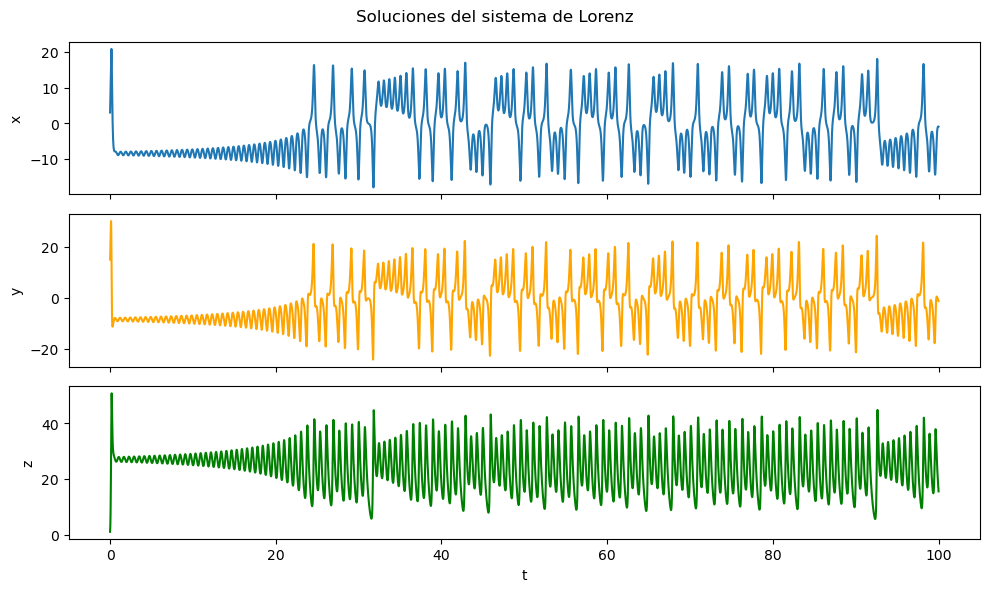

In [16]:
fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axs[0].plot(t, x); axs[0].set_ylabel('x')
axs[1].plot(t, y, color='orange'); axs[1].set_ylabel('y')
axs[2].plot(t, z, color='green'); axs[2].set_ylabel('z')
axs[2].set_xlabel('t')
plt.suptitle('Soluciones del sistema de Lorenz')
plt.tight_layout()
plt.show()

Y la trayectoria en 3D, donde se ve el famoso atractor con forma de mariposa:

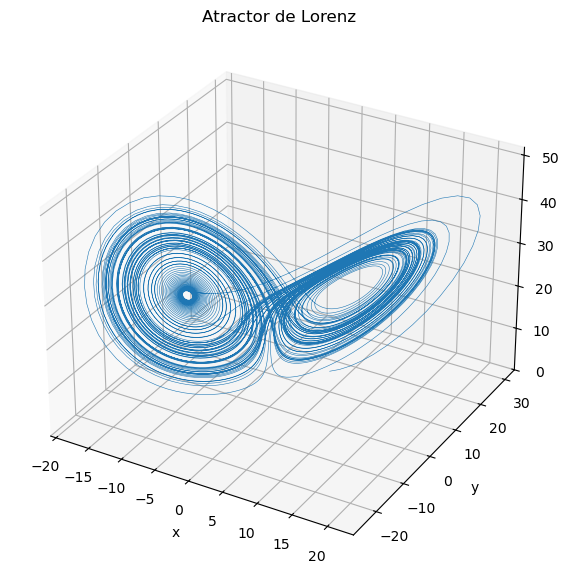

In [17]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=0.4)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Atractor de Lorenz')
plt.show()

Se observa el atractor de Lorenz con la forma de mariposa típica. La trayectoria nunca se repite y va saltando de un lóbulo a otro de manera impredecible.

## Caso 2: cambio de condiciones iniciales

Probamos con otra condición inicial muy parecida, $(3.01, 15, 1)$ en lugar de $(3, 15, 1)$, y la dibujamos junto a la anterior para ver qué pasa.

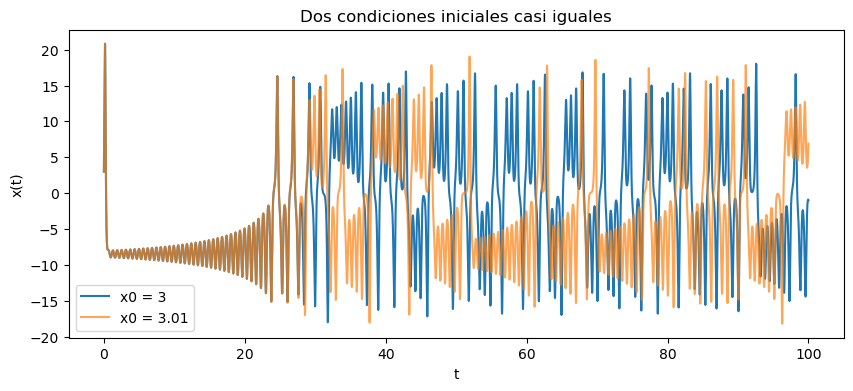

In [18]:
y0_b = [3.01, 15, 1]
t_b, sol_b = rk4(lorenz, y0_b, 0, 100, h, sigma, rho, beta)
x_b, y_b, z_b = sol_b[:, 0], sol_b[:, 1], sol_b[:, 2]

# Comparamos x(t) de las dos soluciones
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='x0 = 3')
plt.plot(t_b, x_b, label='x0 = 3.01', alpha=0.7)
plt.xlabel('t')
plt.ylabel('x(t)')
plt.legend()
plt.title('Dos condiciones iniciales casi iguales')
plt.show()

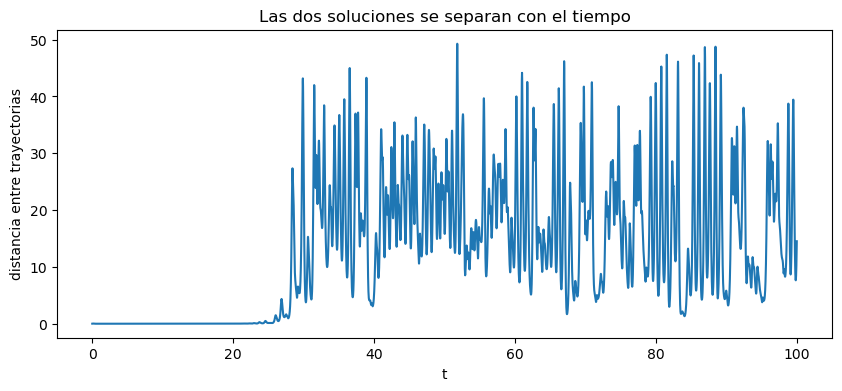

In [19]:
# Distancia entre las dos trayectorias
distancia = np.sqrt((x - x_b)**2 + (y - y_b)**2 + (z - z_b)**2)

plt.figure(figsize=(10, 4))
plt.plot(t, distancia)
plt.xlabel('t')
plt.ylabel('distancia entre trayectorias')
plt.title('Las dos soluciones se separan con el tiempo')
plt.show()

**Comentario.** Aunque las dos condiciones iniciales se parecen mucho (solo cambian en 0.01 en la $x$), las dos soluciones empiezan iguales pero a partir de un cierto momento se separan completamente y siguen caminos distintos. Esto es lo que se llama el *efecto mariposa*: en un sistema caótico, una pequeña diferencia inicial se va amplificando hasta que las trayectorias no tienen nada que ver. Por eso aunque las ecuaciones sean deterministas, no se puede predecir el comportamiento a largo plazo si no conocemos las condiciones iniciales con precisión infinita.

## Aporte personal: animación de trayectorias cercanas

La comparación anterior se entiende mejor si vemos las trayectorias moviéndose a la vez. En esta animación se usan tres condiciones iniciales casi iguales y colores neón para distinguirlas con claridad. La cola de cada curva deja ver el camino reciente sin saturar la figura.

In [20]:
# Condiciones iniciales muy cercanas
condiciones_animacion = [
    ([3, 15, 1], 'x0 = 3.00', '#00F5FF'),
    ([3.01, 15, 1], 'x0 = 3.01', '#FF2E88'),
    ([3, 15.01, 1], 'y0 = 15.01', '#B6FF00'),
]

# Usamos un intervalo más corto para que la animación sea ligera y fluida
t_animacion = None
soluciones_animacion = []
salto = 8
cola = 230

for condicion, etiqueta, color in condiciones_animacion:
    t_temp, sol_temp = rk4(lorenz, condicion, 0, 35, h, sigma, rho, beta)
    t_animacion = t_temp[::salto]
    soluciones_animacion.append((etiqueta, color, sol_temp[::salto]))

todos_puntos = np.vstack([solucion for _, _, solucion in soluciones_animacion])
minimos = todos_puntos.min(axis=0) - 3
maximos = todos_puntos.max(axis=0) + 3

plt.rcParams['animation.embed_limit'] = 80
fig = plt.figure(figsize=(9, 7), facecolor='#070A12')
ax = fig.add_subplot(111, projection='3d', facecolor='#070A12')

# Estilo oscuro con colores brillantes
for eje in (ax.xaxis, ax.yaxis, ax.zaxis):
    eje.pane.set_facecolor('#070A12')
    eje.pane.set_edgecolor('#28304A')

ax.tick_params(colors='#C9D4FF')
ax.set_xlabel('x', color='#E6ECFF')
ax.set_ylabel('y', color='#E6ECFF')
ax.set_zlabel('z', color='#E6ECFF')
ax.set_xlim(minimos[0], maximos[0])
ax.set_ylim(minimos[1], maximos[1])
ax.set_zlim(minimos[2], maximos[2])
ax.set_box_aspect((1, 1, 0.8))
ax.view_init(elev=24, azim=-58)
ax.set_title('Evolución de soluciones casi iguales', color='white', pad=18)

lineas = []
puntos = []
for etiqueta, color, solucion in soluciones_animacion:
    ax.plot(solucion[:, 0], solucion[:, 1], solucion[:, 2], color=color, lw=0.35, alpha=0.10)
    linea, = ax.plot([], [], [], color=color, lw=1.9, alpha=0.95, label=etiqueta)
    punto, = ax.plot([], [], [], marker='o', color=color, markersize=5.5)
    lineas.append(linea)
    puntos.append(punto)

texto_tiempo = ax.text2D(0.03, 0.94, '', transform=ax.transAxes, color='#E6ECFF')
leyenda = ax.legend(loc='upper right', facecolor='#101624', edgecolor='#384466')
for texto in leyenda.get_texts():
    texto.set_color('#E6ECFF')

def actualizar(frame):
    inicio = max(0, frame - cola)

    for linea, punto, (_, _, solucion) in zip(lineas, puntos, soluciones_animacion):
        tramo = solucion[inicio:frame + 1]
        actual = solucion[frame]
        linea.set_data(tramo[:, 0], tramo[:, 1])
        linea.set_3d_properties(tramo[:, 2])
        punto.set_data([actual[0]], [actual[1]])
        punto.set_3d_properties([actual[2]])

    texto_tiempo.set_text(f't = {t_animacion[frame]:.2f}')
    ax.view_init(elev=24, azim=-58 + 0.04*frame)
    return lineas + puntos + [texto_tiempo]

animacion = FuncAnimation(
    fig,
    actualizar,
    frames=len(t_animacion),
    interval=45,
    blit=False,
    repeat=True
)

plt.close(fig)
HTML(animacion.to_jshtml(fps=22))

KeyboardInterrupt: 

## Caso 3: otros valores de los parámetros

Ahora repetimos con $\rho = 14$ y luego con $\rho = 99.6$, manteniendo $\sigma=10$ y $\beta=8/3$ y la condición inicial original.

### Caso $\rho = 14$

In [ ]:
t2, sol2 = rk4(lorenz, [3, 15, 1], 0, 100, h, 10, 14, 8/3)
x2, y2, z2 = sol2[:, 0], sol2[:, 1], sol2[:, 2]

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
axs[0].plot(t2, x2, label='x')
axs[0].plot(t2, y2, label='y')
axs[0].plot(t2, z2, label='z')
axs[0].set_xlabel('t'); axs[0].legend()
axs[0].set_title('Soluciones para rho = 14')

ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.plot(x2, y2, z2, lw=0.5)
ax3d.set_xlabel('x'); ax3d.set_ylabel('y'); ax3d.set_zlabel('z')
ax3d.set_title('Trayectoria 3D')
axs[1].remove()
plt.tight_layout()
plt.show()

print("Valor final:", sol2[-1])

**Comentario.** Con $\rho = 14$ el sistema ya no es caótico. Las soluciones oscilan al principio pero las oscilaciones se van amortiguando hasta que se estabilizan en un punto fijo. En 3D se ve cómo la trayectoria hace una espiral que va cerrándose hacia ese punto. Aquí sí se puede predecir el comportamiento a largo plazo.

### Caso $\rho = 99.6$

In [ ]:
t3, sol3 = rk4(lorenz, [3, 15, 1], 0, 100, h, 10, 99.6, 8/3)
x3, y3, z3 = sol3[:, 0], sol3[:, 1], sol3[:, 2]

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
# Nos quedamos con la parte final, después del transitorio
mask = t3 > 60
axs[0].plot(t3[mask], x3[mask], label='x')
axs[0].plot(t3[mask], y3[mask], label='y')
axs[0].plot(t3[mask], z3[mask], label='z')
axs[0].set_xlabel('t'); axs[0].legend()
axs[0].set_title('Soluciones para rho = 99.6 (a partir de t=60)')

ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.plot(x3[mask], y3[mask], z3[mask], lw=0.5, color='green')
ax3d.set_xlabel('x'); ax3d.set_ylabel('y'); ax3d.set_zlabel('z')
ax3d.set_title('Trayectoria 3D')
axs[1].remove()
plt.tight_layout()
plt.show()

**Comentario.** Con $\rho = 99.6$ el sistema tampoco es caótico, pero se comporta distinto que antes. Las soluciones se vuelven periódicas: oscilan repitiendo el mismo patrón una y otra vez. En 3D se ve una curva cerrada (un ciclo). No converge a un punto como en el caso $\rho=14$, sino que se queda dando vueltas siempre por el mismo camino.

## Aporte personal: vista del atractor desde varios ángulos

Para ver mejor la forma del atractor caótico, dibujamos el mismo atractor pero girando la cámara.

In [ ]:
fig = plt.figure(figsize=(12, 10))
angulos = [(20, -60), (20, 30), (90, 0), (0, 0)]
titulos = ['Vista por defecto', 'Girado 90 grados', 'Visto desde arriba', 'Visto de frente']

for i in range(4):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    ax.plot(x, y, z, lw=0.3)
    ax.view_init(elev=angulos[i][0], azim=angulos[i][1])
    ax.set_title(titulos[i])
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.tight_layout()
plt.show()

Visto desde arriba se aprecian muy bien los dos lóbulos de la mariposa.

## Conclusiones

- El método RK4 con paso $h=0.01$ funciona bien para resolver las ecuaciones de Lorenz.
- Con los parámetros clásicos ($\rho = 28$) el sistema es caótico y aparece el atractor con forma de mariposa.
- Si cambiamos un poco las condiciones iniciales, al principio las soluciones son iguales pero luego se separan mucho. Esto es el efecto mariposa.
- Con $\rho = 14$ el sistema deja de ser caótico y converge a un punto fijo.
- Con $\rho = 99.6$ el sistema es periódico: las soluciones se repiten cíclicamente.
- En resumen, el comportamiento del sistema depende mucho de los parámetros: puede ser estable, periódico o caótico.

## Referencias

- Apuntes de la asignatura.
- Wikipedia: *Sistema de Lorenz* (https://es.wikipedia.org/wiki/Sistema_de_Lorenz)
- Wikipedia: *Método de Runge-Kutta*
- Se ha usado el asistente Claude (Anthropic) para resolver dudas sobre matplotlib y revisar el código.